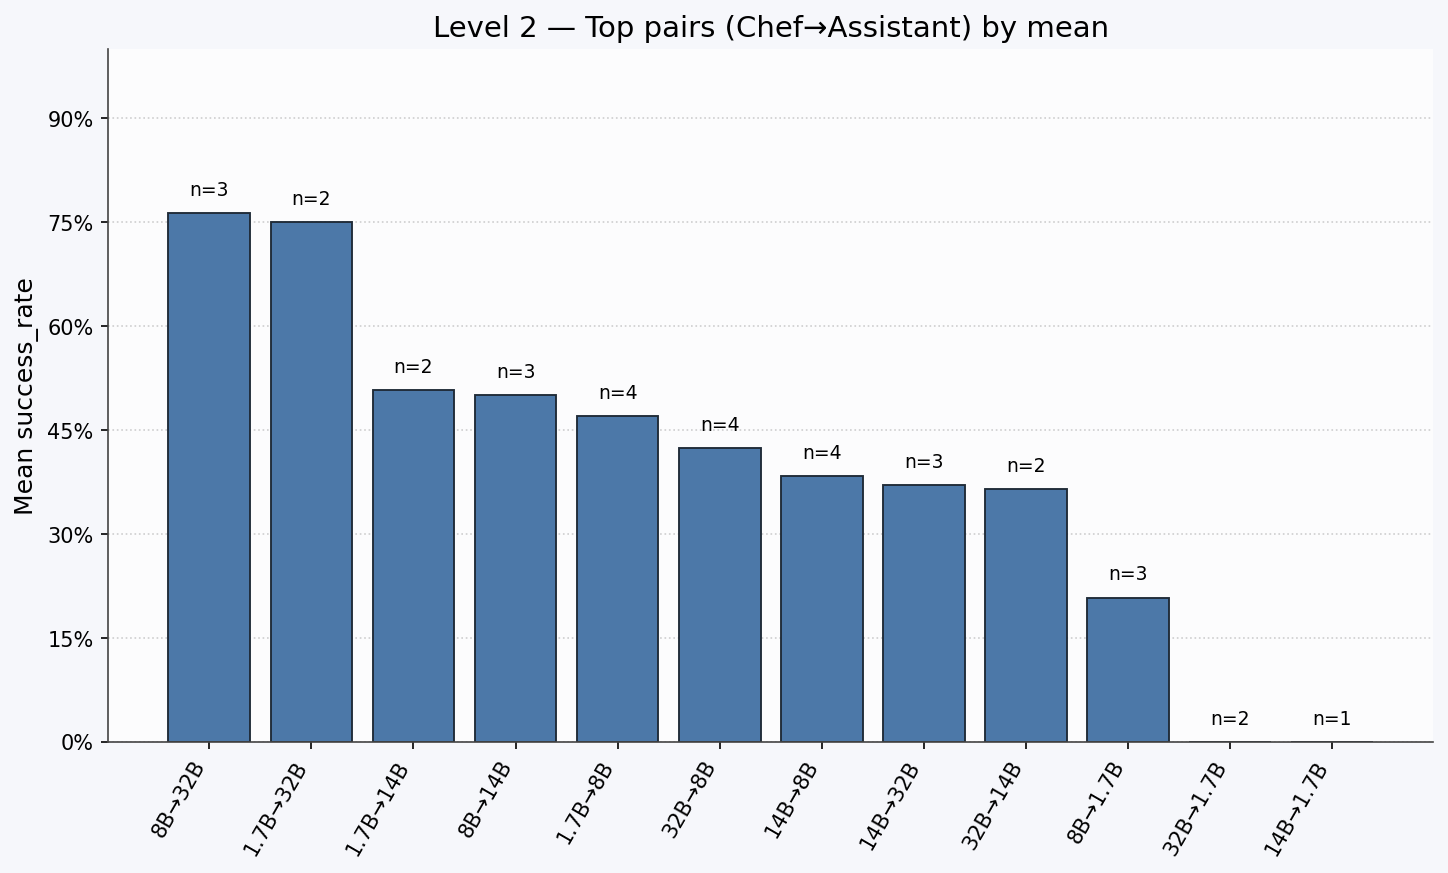

Saved -> ./plots/level_2__top_pairs.png


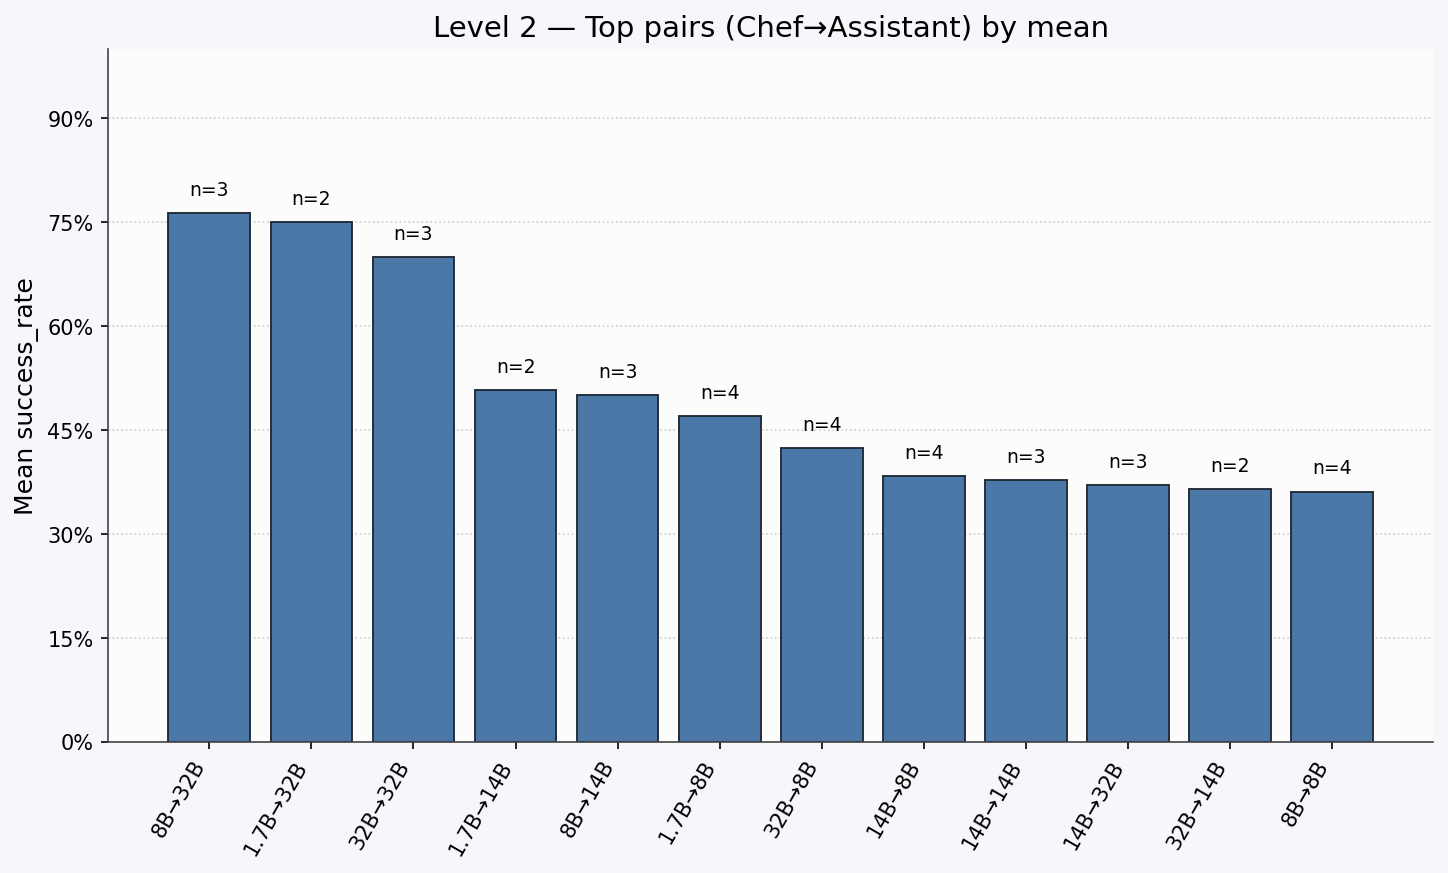

Saved -> ./plots/level_2__top_pairs.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80071/141883612.py:432: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = plt.cm.get_cmap("Blues", max(10, len(chef_sizes)))
/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80071/141883612.py:451: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_A = plt.cm.get_cmap("Blues", max(10, len(assistant_sizes)))


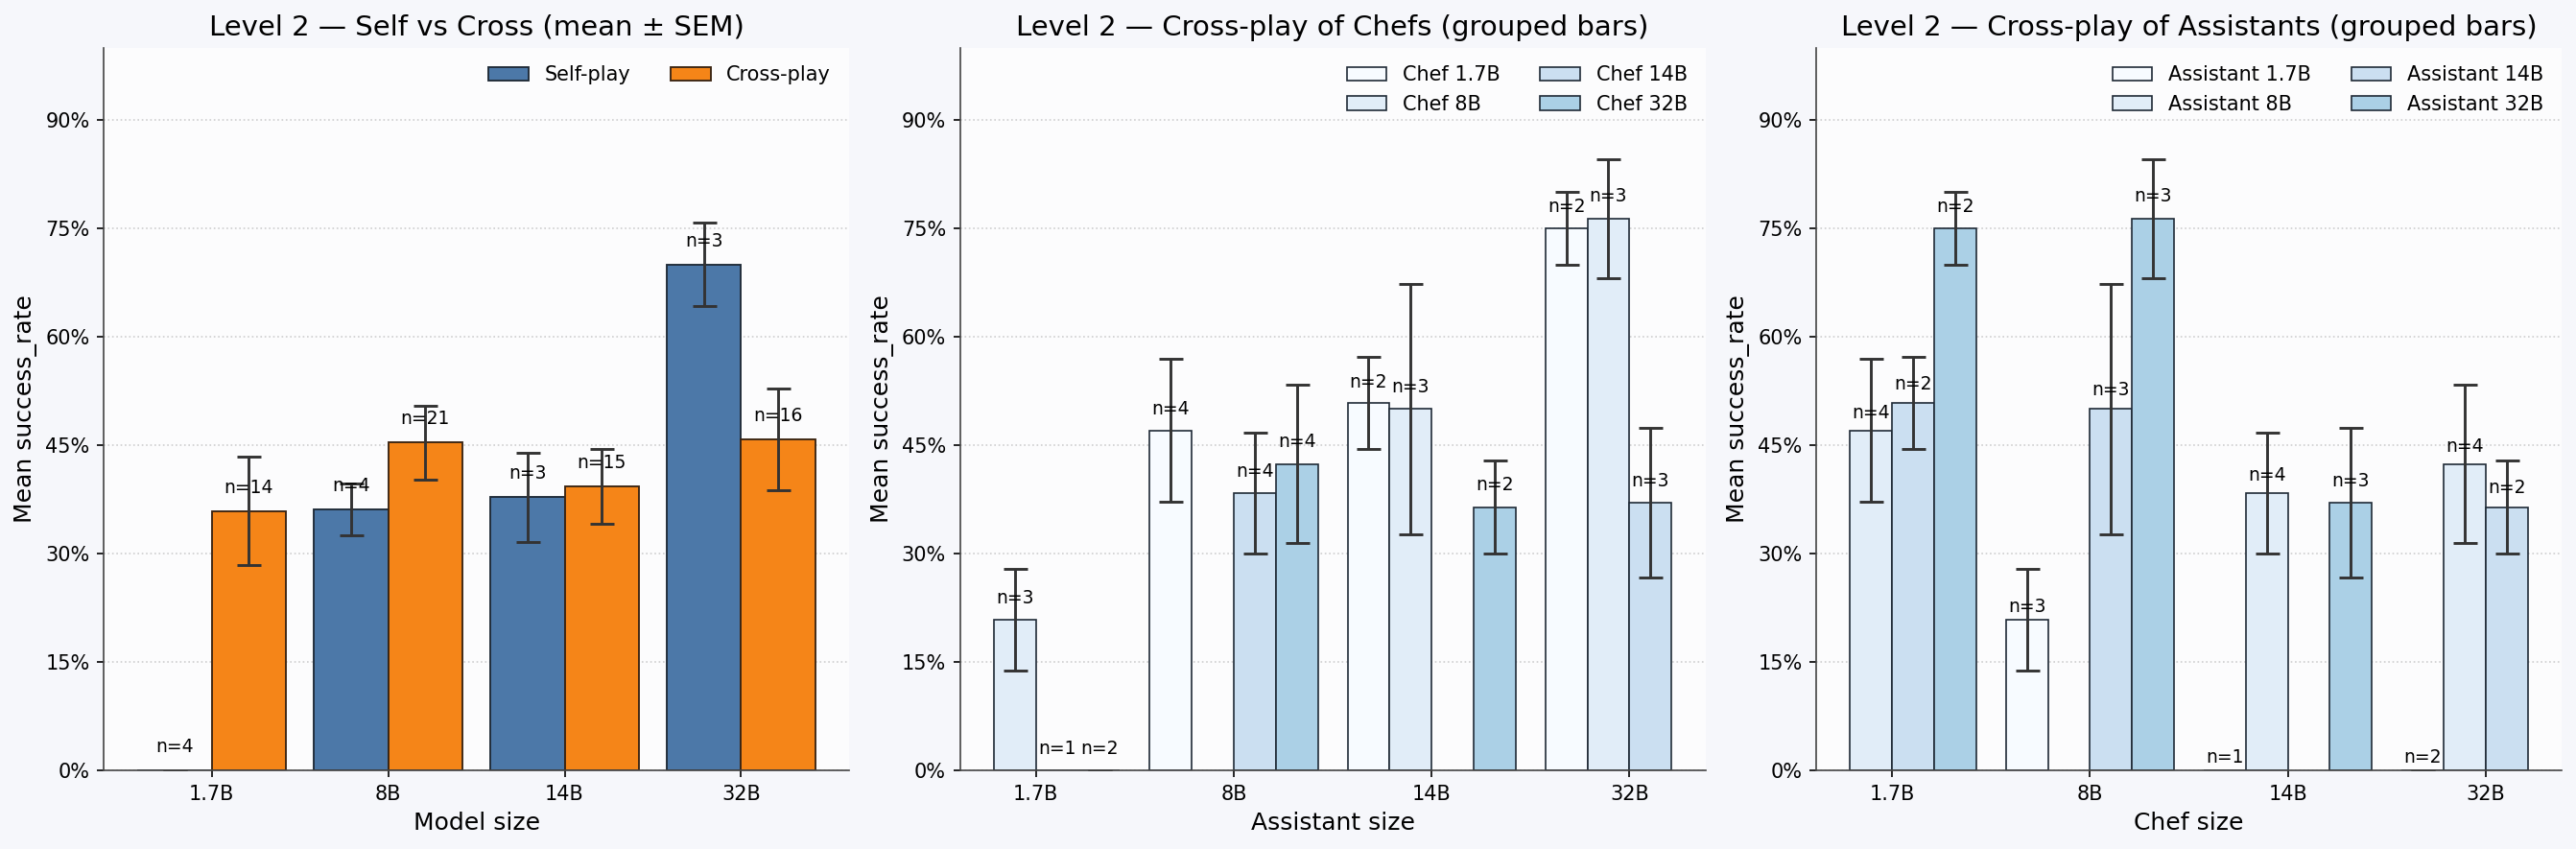

Saved -> ./plots/level_2__composite_bars.png
[Level 2] sizes: ['1.7B', '8B', '14B', '32B']
  Chef sizes: ['1.7B', '8B', '14B', '32B']
  Assistant sizes: ['1.7B', '8B', '14B', '32B']


In [4]:
# NumPy + matplotlib (no pandas)
# Per-level composite figure with 3 panels:
#   (1) Self vs Cross — mean success_rate ± SEM by model size (grouped bars)
#   (2) Cross-play of Chefs — x=Assistant size, series=Chef size (grouped bars)
#   (3) Cross-play of Assistants — x=Chef size, series=Assistant size (grouped bars)
#
# Role mapping (agreed):
#   agent_0 = Chef (first model in 'model' string)
#   agent_1 = Assistant (second model in 'model' string)

import os
import numpy as np
import csv
import re
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from collections import defaultdict

# ---------- Config ----------
INPUT_CANDIDATES = ["statistics_data_symmetric_data.csv"]
OUT_DIR = "./plots"
VERBOSE_SUMMARY = True   # set False to suppress console summaries
SHOW_IN_NOTEBOOK = True  # show figures inline (and also save them)

# Distinct, readable base colors for self/cross; series will use a palette.
COLORS = {"self": "#4C78A8", "cross": "#F58518"}  # blue / orange

# Whether to draw "n=.." on top of each bar
ANNOTATE_COUNTS = True

# Style tweaks for a clean, modern look
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
})

# ---------- Helpers ----------
def find_path(cands):
    for p in cands:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV at any of: {cands}")

def parse_pair(model_str):
    # Expect pattern like "Vendor_ModelA-Vsize_Vendor_ModelB-Vsize"
    parts = model_str.split("_")
    if len(parts) >= 4:
        a = parts[0] + "_" + parts[1]  # agent_0 (Chef)
        b = parts[2] + "_" + parts[3]  # agent_1 (Assistant)
    else:
        mid = len(parts) // 2
        a = "_".join(parts[:mid])
        b = "_".join(parts[mid:])
    return a, b

_size_regex = re.compile(r'(\d+(?:\.\d+)?)\s*[Bb]\b')

def extract_size(label):
    # Try last hyphen token first (e.g., "Qwen3-32B" -> "32B")
    toks = label.split("-")
    for tok in reversed(toks):
        tok = tok.strip()
        if tok and (tok[-1] in "Bb"):
            m = _size_regex.match(tok)
            if m:
                num = m.group(1)
                return f"{num}B"
    # Fallback: search anywhere
    m = _size_regex.search(label)
    if m:
        return f"{m.group(1)}B"
    return None

def sem(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return float("nan")
    return float(np.std(x, ddof=1) / np.sqrt(n))

def size_key(sz):
    try:
        return float(sz[:-1])
    except Exception:
        return float("inf")

def polish_axes(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_facecolor("#FCFCFD")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

def format_as_percent_if_applicable(ax, ymax_est):
    # If success_rate is in [0,1], swap to % ticks.
    if np.isfinite(ymax_est) and ymax_est <= 1.05:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v*100:.0f}%"))
        ax.set_ylim(0, max(1.0, ymax_est))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

def sanitize_token(s):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s))

def show_and_save(fig, path):
    # display first (for notebooks), then save, then close
    if SHOW_IN_NOTEBOOK:
        try:
            from IPython.display import display
            display(fig)
        except Exception:
            try:
                plt.show()
            except Exception:
                pass
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("Saved ->", path)

def collect_mean_sem_n(vals):
    vals = np.asarray(vals, dtype=float)
    n = int(vals.size)
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(np.mean(vals)), sem(vals), n

def plot_grouped_bars(ax, x_labels, series_keys, mean_map, sem_map, n_map,
                      color_map, label_prefix, error_kw):
    """
    x_labels: ordered list of category labels for the x-axis
    series_keys: ordered list of series (each will be a grouped bar)
    mean_map[series_key][x_label] -> mean
    sem_map[series_key][x_label]  -> sem
    n_map[series_key][x_label]    -> n
    color_map: callable int->color, e.g., plt.cm.get_cmap("tab10", K)
    """
    x = np.arange(len(x_labels), dtype=float)
    k = max(1, len(series_keys))
    width = min(0.85 / k, 0.28)  # keep bars readable even with many series

    ymax_est = 0.0
    for i, sk in enumerate(series_keys):
        heights = [mean_map[sk].get(lbl, float("nan")) for lbl in x_labels]
        errors  = [sem_map[sk].get(lbl,  float("nan")) for lbl in x_labels]
        counts  = [n_map[sk].get(lbl,    0)             for lbl in x_labels]

        # Bar centers for this series
        pos = x + (i - (k - 1) / 2.0) * width

        bars = ax.bar(pos, heights, width,
                      yerr=errors,
                      label=f"{label_prefix} {sk}",
                      color=color_map(i),
                      edgecolor="#1f2a36",
                      linewidth=0.8,
                      error_kw=error_kw)

        # Annotation and local ymax aggregation
        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin if ymax > ymin else 1.0
        for rect, h, n in zip(bars, heights, counts):
            if not np.isfinite(h):
                continue
            ymax_est = max(ymax_est, float(h) + (errors[0] if (len(errors) and np.isfinite(errors[0])) else 0.0))
            if ANNOTATE_COUNTS:
                ax.text(rect.get_x() + rect.get_width()/2.0,
                        rect.get_height() + 0.02 * yrange,
                        f"n={n}", ha="center", va="bottom", fontsize=9)

    # Finalize x axis
    ax.set_xticks(x, x_labels)
    return ymax_est

# ---------- Load ----------
path = find_path(INPUT_CANDIDATES)

# Aggregates
# buckets_by_size[(level, size, type)] -> list[success_rate], type in {"self","cross"}  (size = generic size bucket)
buckets_by_size = defaultdict(list)

# Cross decomposition matrices (role aware)
# cross_matrix[level][chef_size][assistant_size] -> list[success_rate]
cross_matrix = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Track which sizes appear as chef vs assistant, per level
chef_sizes_by_level = defaultdict(set)
assistant_sizes_by_level = defaultdict(set)

levels_seen = set()
sizes_seen_by_level = defaultdict(set)  # for combined self vs cross chart

with open(path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            sr = float(row["success_rate"])
            model_str = row["model"]
            level = row["level"]
        except (KeyError, ValueError):
            continue
        if not level:
            continue

        a, b = parse_pair(model_str)
        sa = extract_size(a)  # agent_0 (Chef)
        sb = extract_size(b)  # agent_1 (Assistant)
        if sa is None or sb is None:
            continue

        levels_seen.add(level)
        sizes_seen_by_level[level].update([sa, sb])

        # Self vs Cross (size-agnostic of role)
        if sa == sb:
            buckets_by_size[(level, sa, "self")].append(sr)
        else:
            # count cross for both sizes in the size-based view
            buckets_by_size[(level, sa, "cross")].append(sr)
            buckets_by_size[(level, sb, "cross")].append(sr)

            # role-aware cross matrices
            cross_matrix[level][sa][sb].append(sr)  # Chef=sa, Assistant=sb
            chef_sizes_by_level[level].add(sa)
            assistant_sizes_by_level[level].add(sb)

# Sort levels (numeric if possible, else lexical)
def level_key(x):
    try:
        return (0, float(x))
    except Exception:
        return (1, str(x))
levels_sorted = sorted(levels_seen, key=level_key)

# ---------- Per-level composite figures (3 panels each) ----------
os.makedirs(OUT_DIR, exist_ok=True)
error_kw_common = dict(ecolor="#333333", linewidth=1.4, capsize=6, capthick=1.4)

for lvl in levels_sorted:

    # Prepare panel (1): Self vs Cross grouped bars by size
    sizes_sorted = sorted(sizes_seen_by_level[lvl], key=size_key)

    means_self_all, sems_self_all, n_self_all = [], [], []
    means_cross_all, sems_cross_all, n_cross_all = [], [], []
    for sz in sizes_sorted:
        xs = np.array(buckets_by_size.get((lvl, sz, "self"), []), dtype=float)
        xc = np.array(buckets_by_size.get((lvl, sz, "cross"), []), dtype=float)

        m_s, s_s, n_s = collect_mean_sem_n(xs)
        m_c, s_c, n_c = collect_mean_sem_n(xc)

        means_self_all.append(m_s); sems_self_all.append(s_s); n_self_all.append(n_s)
        means_cross_all.append(m_c); sems_cross_all.append(s_c); n_cross_all.append(n_c)

    # Prepare panels (2) and (3): role-aware cross matrices
    chef_sizes = sorted(chef_sizes_by_level[lvl], key=size_key)
    assistant_sizes = sorted(assistant_sizes_by_level[lvl], key=size_key)

    # Build mean/sem/n maps for grouped bars
    # (2) series=Chef size, x=Assistant size
    means_Chef, sems_Chef, ns_Chef = {}, {}, {}
    for csz in chef_sizes:
        means_Chef[csz], sems_Chef[csz], ns_Chef[csz] = {}, {}, {}
        for asz in assistant_sizes:
            m, s, n = collect_mean_sem_n(cross_matrix[lvl][csz].get(asz, []))
            means_Chef[csz][asz] = m
            sems_Chef[csz][asz] = s
            ns_Chef[csz][asz] = n

    # (3) series=Assistant size, x=Chef size
    means_Asst, sems_Asst, ns_Asst = {}, {}, {}
    for asz in assistant_sizes:
        means_Asst[asz], sems_Asst[asz], ns_Asst[asz] = {}, {}, {}
        for csz in chef_sizes:
            m, s, n = collect_mean_sem_n(cross_matrix[lvl][csz].get(asz, []))
            means_Asst[asz][csz] = m
            sems_Asst[asz][csz] = s
            ns_Asst[asz][csz] = n

    # Create the 1x3 composite figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor("#F6F7FB")

    # ========= Panel (1): Self vs Cross =========
    ax = axes[0]
    x = np.arange(len(sizes_sorted))
    width = 0.42

    # ymax estimate for percent formatting
    a = np.nan_to_num(np.array(means_self_all),  nan=0.0) + np.nan_to_num(np.array(sems_self_all),  nan=0.0)
    b = np.nan_to_num(np.array(means_cross_all), nan=0.0) + np.nan_to_num(np.array(sems_cross_all), nan=0.0)
    ymax_est1 = float(max(np.max(a) if a.size else 0.0, np.max(b) if b.size else 0.0))

    b1 = ax.bar(x - width/2, means_self_all,  width, yerr=sems_self_all,  label="Self-play",
                color=COLORS["self"],  edgecolor="#1f2a36", linewidth=0.9, error_kw=error_kw_common)
    b2 = ax.bar(x + width/2, means_cross_all, width, yerr=sems_cross_all, label="Cross-play",
                color=COLORS["cross"], edgecolor="#3a2412", linewidth=0.9, error_kw=error_kw_common)

    ax.set_xticks(x, sizes_sorted)
    ax.set_xlabel("Model size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Self vs Cross (mean ± SEM)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est1)
    ax.legend(frameon=False, ncol=2)

    # annotate sample sizes
    ymin, ymax = ax.get_ylim(); yrange = ymax - ymin
    for rect, n in zip(b1, n_self_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)
    for rect, n in zip(b2, n_cross_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)

    # ========= Panel (2): Cross-play of Chefs (grouped bars) =========
    ax = axes[1]
    cmap_C = plt.cm.get_cmap("Blues", max(10, len(chef_sizes)))
    ymax_est2 = plot_grouped_bars(ax,
                                  x_labels=assistant_sizes,
                                  series_keys=chef_sizes,
                                  mean_map=means_Chef,
                                  sem_map=sems_Chef,
                                  n_map=ns_Chef,
                                  color_map=cmap_C,
                                  label_prefix="Chef",
                                  error_kw=error_kw_common)
    ax.set_xlabel("Assistant size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Cross-play of Chefs (grouped bars)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est2 if np.isfinite(ymax_est2) else np.nan)
    ax.legend(frameon=False, ncol=2)

    # ========= Panel (3): Cross-play of Assistants (grouped bars) =========
    ax = axes[2]
    cmap_A = plt.cm.get_cmap("Blues", max(10, len(assistant_sizes)))
    ymax_est3 = plot_grouped_bars(ax,
                                  x_labels=chef_sizes,
                                  series_keys=assistant_sizes,
                                  mean_map=means_Asst,
                                  sem_map=sems_Asst,
                                  n_map=ns_Asst,
                                  color_map=cmap_A,
                                  label_prefix="Assistant",
                                  error_kw=error_kw_common)
    ax.set_xlabel("Chef size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Cross-play of Assistants (grouped bars)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est3 if np.isfinite(ymax_est3) else np.nan)
    ax.legend(frameon=False, ncol=2)

    # Layout + save
    fig.tight_layout()
    composite_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__composite_bars.png")
    show_and_save(fig, composite_png)

    if VERBOSE_SUMMARY:
        print(f"[Level {lvl}] sizes: {sizes_sorted}")
        print(f"  Chef sizes: {chef_sizes}")
        print(f"  Assistant sizes: {assistant_sizes}")


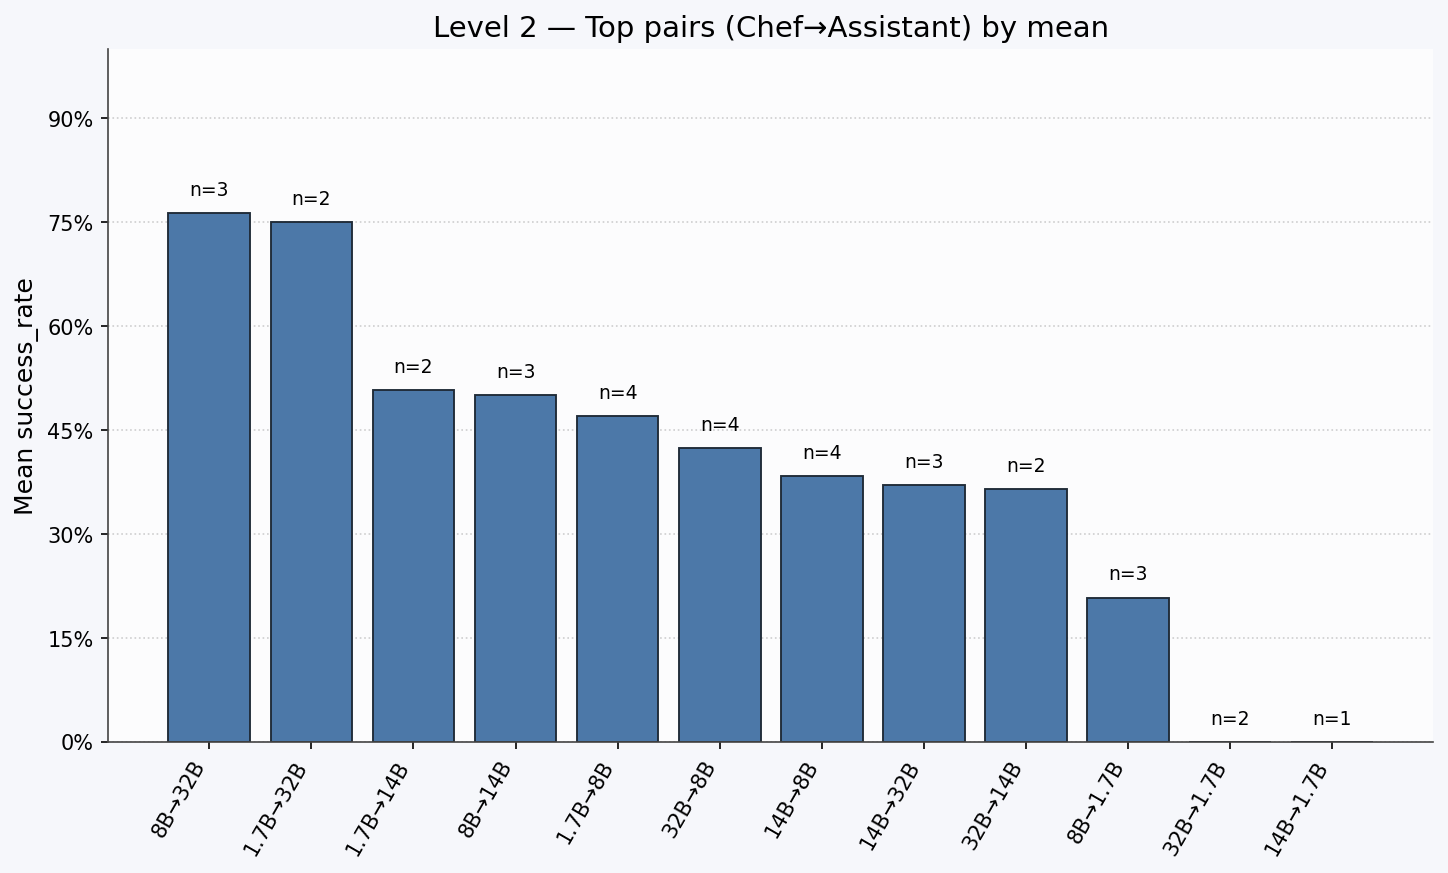

Saved -> ./plots/level_2__top_pairs.png


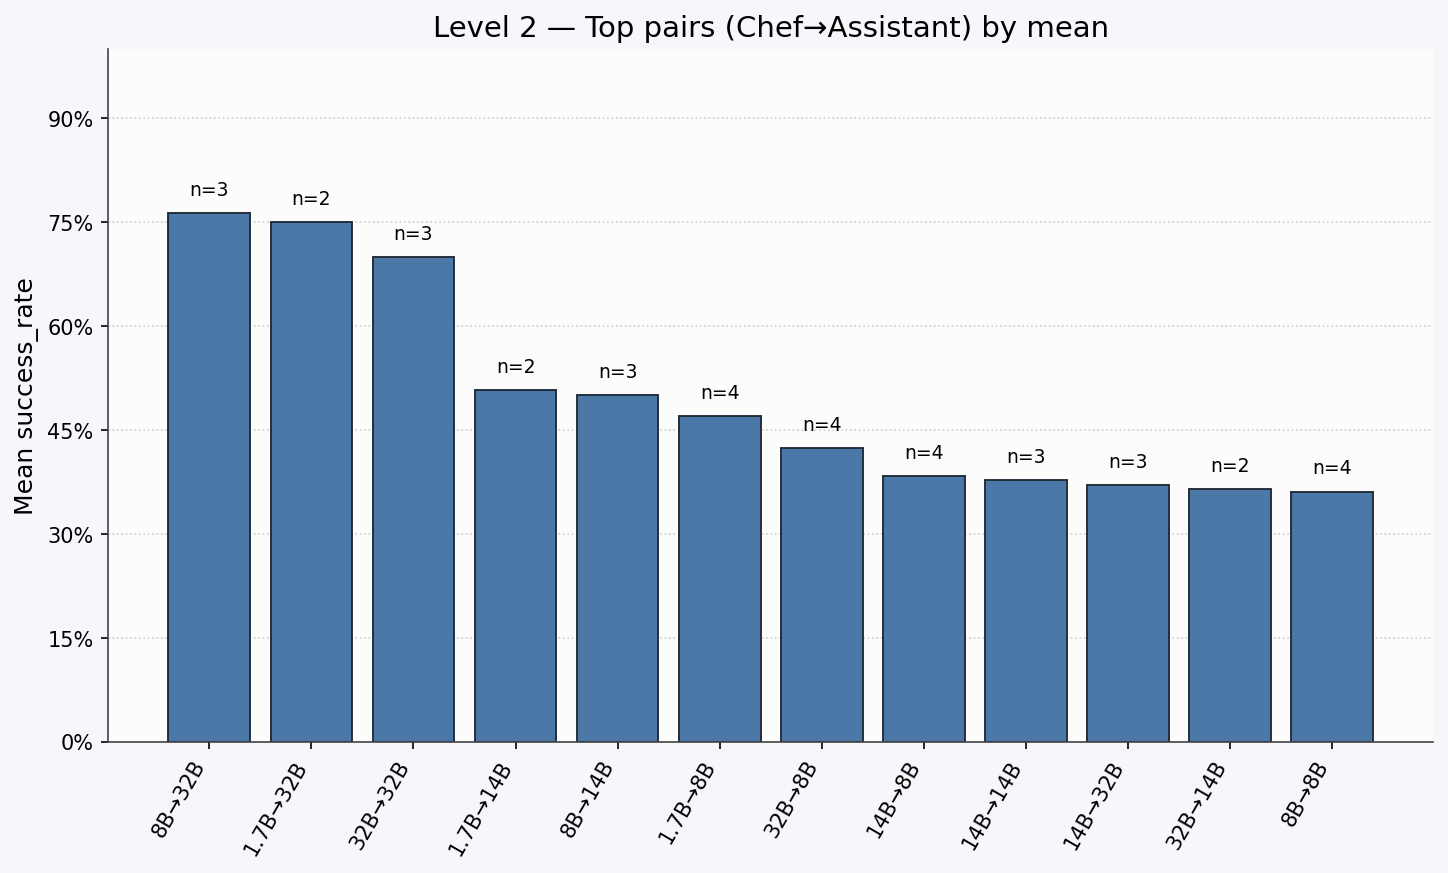

Saved -> ./plots/level_2__top_pairs.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80071/1427865920.py:463: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = plt.cm.get_cmap("Blues", max(10, len(series_Chef)))
/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80071/1427865920.py:483: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_A = plt.cm.get_cmap("Blues", max(10, len(series_Asst)))


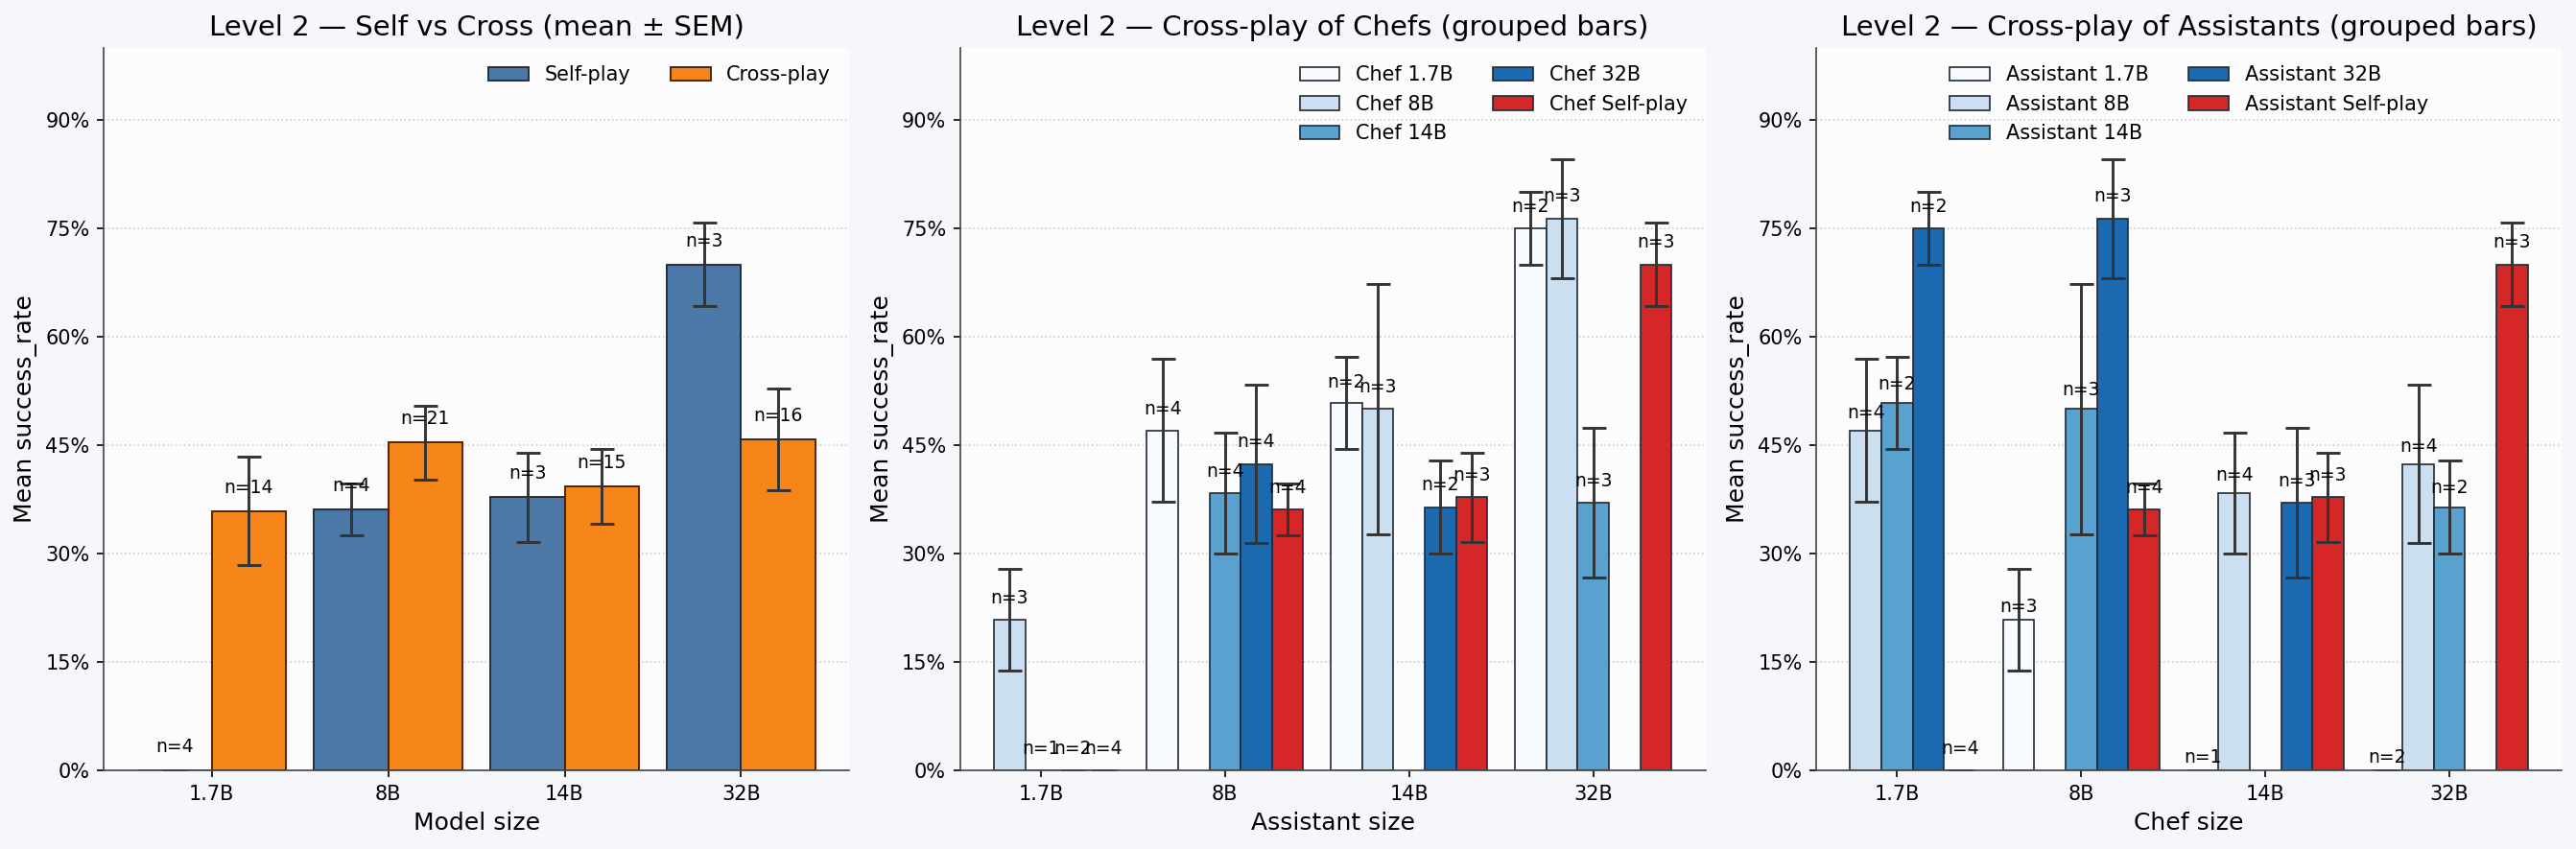

Saved -> ./plots/level_2__composite_bars.png
[Level 2] sizes: ['1.7B', '8B', '14B', '32B']
  Chef sizes: ['1.7B', '8B', '14B', '32B']
  Assistant sizes: ['1.7B', '8B', '14B', '32B']


In [5]:
# NumPy + matplotlib (no pandas)
# Per-level composite figure with 3 panels:
#   (1) Self vs Cross — mean success_rate ± SEM by model size (grouped bars)
#   (2) Cross-play of Chefs — x=Assistant size, series=Chef size (grouped bars) + Self-play (red)
#   (3) Cross-play of Assistants — x=Chef size, series=Assistant size (grouped bars) + Self-play (red)
#
# Role mapping (agreed):
#   agent_0 = Chef (first model in 'model' string)
#   agent_1 = Assistant (second model in 'model' string)

import os
import numpy as np
import csv
import re
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from collections import defaultdict

# ---------- Config ----------
INPUT_CANDIDATES = ["statistics_data_symmetric_data.csv"]
OUT_DIR = "./plots"
VERBOSE_SUMMARY = True   # set False to suppress console summaries
SHOW_IN_NOTEBOOK = True  # show figures inline (and also save them)

# Distinct, readable base colors for self/cross; series will use a palette.
COLORS = {"self": "#4C78A8", "cross": "#F58518"}  # blue / orange
SELFPLAY_RED = "#D62728"

# Whether to draw "n=.." on top of each bar
ANNOTATE_COUNTS = True

# Style tweaks for a clean, modern look
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
})

# ---------- Helpers ----------
def find_path(cands):
    for p in cands:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV at any of: {cands}")

def parse_pair(model_str):
    # Expect pattern like "Vendor_ModelA-Vsize_Vendor_ModelB-Vsize"
    parts = model_str.split("_")
    if len(parts) >= 4:
        a = parts[0] + "_" + parts[1]  # agent_0 (Chef)
        b = parts[2] + "_" + parts[3]  # agent_1 (Assistant)
    else:
        mid = len(parts) // 2
        a = "_".join(parts[:mid])
        b = "_".join(parts[mid:])
    return a, b

_size_regex = re.compile(r'(\d+(?:\.\d+)?)\s*[Bb]\b')

def extract_size(label):
    # Try last hyphen token first (e.g., "Qwen3-32B" -> "32B")
    toks = label.split("-")
    for tok in reversed(toks):
        tok = tok.strip()
        if tok and (tok[-1] in "Bb"):
            m = _size_regex.match(tok)
            if m:
                num = m.group(1)
                return f"{num}B"
    # Fallback: search anywhere
    m = _size_regex.search(label)
    if m:
        return f"{m.group(1)}B"
    return None

def sem(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return float("nan")
    return float(np.std(x, ddof=1) / np.sqrt(n))

def size_key(sz):
    try:
        return float(sz[:-1])
    except Exception:
        return float("inf")

def polish_axes(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_facecolor("#FCFCFD")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

def format_as_percent_if_applicable(ax, ymax_est):
    # If success_rate is in [0,1], swap to % ticks.
    if np.isfinite(ymax_est) and ymax_est <= 1.05:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v*100:.0f}%"))
        ax.set_ylim(0, max(1.0, ymax_est))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

def sanitize_token(s):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s))

def show_and_save(fig, path):
    # display first (for notebooks), then save, then close
    if SHOW_IN_NOTEBOOK:
        try:
            from IPython.display import display
            display(fig)
        except Exception:
            try:
                plt.show()
            except Exception:
                pass
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("Saved ->", path)

def collect_mean_sem_n(vals):
    vals = np.asarray(vals, dtype=float)
    n = int(vals.size)
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(np.mean(vals)), sem(vals), n

def _safe_color_from_map(cmap, i, k):
    # Map series index to [0,1] for robust colormap sampling
    if k <= 1:
        t = 0.5
    else:
        t = i / (k - 1)
    return cmap(t)

def plot_grouped_bars(ax, x_labels, series_keys, mean_map, sem_map, n_map,
                      color_map, label_prefix, error_kw, color_for=None):
    """
    x_labels: ordered list of category labels for the x-axis
    series_keys: ordered list of series (each will be a grouped bar)
    mean_map[series_key][x_label] -> mean
    sem_map[series_key][x_label]  -> sem
    n_map[series_key][x_label]    -> n
    color_map: callable float->color, e.g., plt.cm.get_cmap("tab10")
    color_for: optional callable (i, series_key) -> color string; overrides color_map when provided.
    """
    x = np.arange(len(x_labels), dtype=float)
    k = max(1, len(series_keys))
    width = min(0.85 / k, 0.28)  # keep bars readable even with many series

    ymax_est = 0.0
    for i, sk in enumerate(series_keys):
        heights = [mean_map[sk].get(lbl, float("nan")) for lbl in x_labels]
        errors  = [sem_map[sk].get(lbl,  float("nan")) for lbl in x_labels]
        counts  = [n_map[sk].get(lbl,    0)             for lbl in x_labels]

        # Bar centers for this series
        pos = x + (i - (k - 1) / 2.0) * width

        color = color_for(i, sk) if color_for is not None else _safe_color_from_map(color_map, i, k)

        bars = ax.bar(pos, heights, width,
                      yerr=errors,
                      label=(f"{label_prefix} {sk}"),
                      color=color,
                      edgecolor="#1f2a36",
                      linewidth=0.8,
                      error_kw=error_kw)

        # Annotation and local ymax aggregation
        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin if ymax > ymin else 1.0
        for rect, h, n, e in zip(bars, heights, counts, errors):
            if not np.isfinite(h):
                continue
            ymax_est = max(ymax_est, float(h) + (e if (np.isfinite(e)) else 0.0))
            if ANNOTATE_COUNTS:
                ax.text(rect.get_x() + rect.get_width()/2.0,
                        rect.get_height() + 0.02 * yrange,
                        f"n={n}", ha="center", va="bottom", fontsize=9)

    # Finalize x axis
    ax.set_xticks(x, x_labels)
    return ymax_est

# ---------- Load ----------
path = find_path(INPUT_CANDIDATES)

# Aggregates
# buckets_by_size[(level, size, type)] -> list[success_rate], type in {"self","cross"}  (size = generic size bucket)
buckets_by_size = defaultdict(list)

# Cross decomposition matrices (role aware)
# cross_matrix[level][chef_size][assistant_size] -> list[success_rate]
cross_matrix = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Track which sizes appear as chef vs assistant, per level
chef_sizes_by_level = defaultdict(set)
assistant_sizes_by_level = defaultdict(set)

levels_seen = set()
sizes_seen_by_level = defaultdict(set)  # for combined self vs cross chart

with open(path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            sr = float(row["success_rate"])
            model_str = row["model"]
            level = row["level"]
        except (KeyError, ValueError):
            continue
        if not level:
            continue

        a, b = parse_pair(model_str)
        sa = extract_size(a)  # agent_0 (Chef)
        sb = extract_size(b)  # agent_1 (Assistant)
        if sa is None or sb is None:
            continue

        levels_seen.add(level)
        sizes_seen_by_level[level].update([sa, sb])

        # Self vs Cross (size-agnostic of role)
        if sa == sb:
            buckets_by_size[(level, sa, "self")].append(sr)
        else:
            # count cross for both sizes in the size-based view
            buckets_by_size[(level, sa, "cross")].append(sr)
            buckets_by_size[(level, sb, "cross")].append(sr)

            # role-aware cross matrices
            cross_matrix[level][sa][sb].append(sr)  # Chef=sa, Assistant=sb
            chef_sizes_by_level[level].add(sa)
            assistant_sizes_by_level[level].add(sb)

# Sort levels (numeric if possible, else lexical)
def level_key(x):
    try:
        return (0, float(x))
    except Exception:
        return (1, str(x))
levels_sorted = sorted(levels_seen, key=level_key)

# ---------- Per-level composite figures (3 panels each) ----------
os.makedirs(OUT_DIR, exist_ok=True)
error_kw_common = dict(ecolor="#333333", linewidth=1.4, capsize=6, capthick=1.4)

for lvl in levels_sorted:
    TOP_PAIRS_COUNT = 12  # number of top Chef→Assistant size pairs to plot
    
    # ========= Top pairs (Chef→Assistant) by mean =========
    pairs = []
    for csz in chef_sizes:
        row_means = means_Chef.get(csz, {})
        row_ns    = ns_Chef.get(csz, {})
        for asz in assistant_sizes:
            m = row_means.get(asz, float("nan"))
            n = row_ns.get(asz, 0)
            if np.isfinite(m) and n > 0:
                # weight tie-breaker by log(n) to prefer well-sampled pairs
                pairs.append((m, math.log(max(1, n) + 1.0), n, csz, asz))
    
    if pairs:
        pairs.sort(key=lambda t: (t[0], t[1]), reverse=True)
        top = pairs[:max(1, TOP_PAIRS_COUNT)]
    
        labels = [f"{cm}→{am}" for (_, _, _, cm, am) in top]
        means  = [m for (m, _, _, _, _) in top]
        counts = [n for (_, _, n, _, _) in top]
    
        fig_tp = plt.figure(figsize=(max(10, 0.45*len(top) + 6), 6))
        ax_tp  = fig_tp.add_subplot(111); fig_tp.patch.set_facecolor("#F6F7FB")
    
        x = np.arange(len(top))
        bars = ax_tp.bar(x, means, edgecolor="#1f2a36", linewidth=0.9, color=COLORS["self"])
        ax_tp.set_xticks(x, labels, rotation=60, ha="right")
        ax_tp.set_ylabel("Mean success_rate")
        ax_tp.set_title(f"Level {lvl} — Top pairs (Chef→Assistant) by mean")
        polish_axes(ax_tp)
    
        ymax_est = float(max(means)) if means else float("nan")
        format_as_percent_if_applicable(ax_tp, ymax_est)
    
        ymin, ymax = ax_tp.get_ylim(); yrange = ymax - ymin
        if ANNOTATE_COUNTS:
            for rect, n in zip(bars, counts):
                h = rect.get_height()
                if np.isfinite(h):
                    ax_tp.text(rect.get_x() + rect.get_width()/2.0,
                               h + 0.02*yrange,
                               f"n={n}",
                               ha="center", va="bottom", fontsize=9)
    
        out_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__top_pairs.png")
        show_and_save(fig_tp, out_png)

    # ========= Top pairs (Chef→Assistant) by mean (with optional self-play) =========
    TOP_PAIRS_COUNT = 12          # you can move this to the global config if preferred
    INCLUDE_SELF_IN_TOP = True    # set False to exclude self-play from this ranking

    pairs = []

    # Cross-play (directional): Chef size = csz, Assistant size = asz
    for csz in chef_sizes:
        row_means = means_Chef.get(csz, {})
        row_ns    = ns_Chef.get(csz, {})
        for asz in assistant_sizes:
            m = row_means.get(asz, float("nan"))
            n = row_ns.get(asz, 0)
            if np.isfinite(m) and n > 0:
                # Tie-break on larger samples via log(n)
                pairs.append((m, math.log(max(1, n) + 1.0), n, csz, asz))

    # Optional: include self-play as directed pairs sz→sz, sourced from self buckets
    if INCLUDE_SELF_IN_TOP:
        for sz in sizes_sorted:
            m_s, s_s, n_s = collect_mean_sem_n(buckets_by_size.get((lvl, sz, "self"), []))
            if np.isfinite(m_s) and n_s > 0:
                pairs.append((m_s, math.log(max(1, n_s) + 1.0), n_s, sz, sz))

    if pairs:
        pairs.sort(key=lambda t: (t[0], t[1]), reverse=True)
        top = pairs[:max(1, TOP_PAIRS_COUNT)]

        labels = [f"{cm}→{am}" for (_, _, _, cm, am) in top]
        means  = [m for (m, _, _, _, _) in top]
        counts = [n for (_, _, n, _, _) in top]

        fig_tp = plt.figure(figsize=(max(10, 0.45*len(top) + 6), 6))
        ax_tp  = fig_tp.add_subplot(111); fig_tp.patch.set_facecolor("#F6F7FB")

        x = np.arange(len(top))
        bars = ax_tp.bar(x, means, edgecolor="#1f2a36", linewidth=0.9, color=COLORS["self"])
        ax_tp.set_xticks(x, labels, rotation=60, ha="right")
        ax_tp.set_ylabel("Mean success_rate")
        ax_tp.set_title(f"Level {lvl} — Top pairs (Chef→Assistant) by mean")
        polish_axes(ax_tp)

        ymax_est = float(max(means)) if means else float("nan")
        format_as_percent_if_applicable(ax_tp, ymax_est)

        ymin, ymax = ax_tp.get_ylim(); yrange = ymax - ymin
        if ANNOTATE_COUNTS:
            for rect, n in zip(bars, counts):
                h = rect.get_height()
                if np.isfinite(h):
                    ax_tp.text(rect.get_x() + rect.get_width()/2.0,
                               h + 0.02*yrange,
                               f"n={n}",
                               ha="center", va="bottom", fontsize=9)

        out_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__top_pairs.png")
        show_and_save(fig_tp, out_png)
        
    # Prepare panel (1): Self vs Cross grouped bars by size
    sizes_sorted = sorted(sizes_seen_by_level[lvl], key=size_key)

    means_self_all, sems_self_all, n_self_all = [], [], []
    means_cross_all, sems_cross_all, n_cross_all = [], [], []
    for sz in sizes_sorted:
        xs = np.array(buckets_by_size.get((lvl, sz, "self"), []), dtype=float)
        xc = np.array(buckets_by_size.get((lvl, sz, "cross"), []), dtype=float)

        m_s, s_s, n_s = collect_mean_sem_n(xs)
        m_c, s_c, n_c = collect_mean_sem_n(xc)

        means_self_all.append(m_s); sems_self_all.append(s_s); n_self_all.append(n_s)
        means_cross_all.append(m_c); sems_cross_all.append(s_c); n_cross_all.append(n_c)

    # Prepare panels (2) and (3): role-aware cross matrices
    chef_sizes = sorted(chef_sizes_by_level[lvl], key=size_key)
    assistant_sizes = sorted(assistant_sizes_by_level[lvl], key=size_key)

    # Build mean/sem/n maps for grouped bars
    # (2) series=Chef size, x=Assistant size
    means_Chef, sems_Chef, ns_Chef = {}, {}, {}
    for csz in chef_sizes:
        means_Chef[csz], sems_Chef[csz], ns_Chef[csz] = {}, {}, {}
        for asz in assistant_sizes:
            m, s, n = collect_mean_sem_n(cross_matrix[lvl][csz].get(asz, []))
            means_Chef[csz][asz] = m
            sems_Chef[csz][asz] = s
            ns_Chef[csz][asz] = n

    # --- Add Self-play (red) as another series over Assistant sizes ---
    SELF_KEY = "Self-play"
    means_Chef[SELF_KEY], sems_Chef[SELF_KEY], ns_Chef[SELF_KEY] = {}, {}, {}
    for asz in assistant_sizes:
        m, s, n = collect_mean_sem_n(buckets_by_size.get((lvl, asz, "self"), []))
        means_Chef[SELF_KEY][asz] = m
        sems_Chef[SELF_KEY][asz]  = s
        ns_Chef[SELF_KEY][asz]    = n
    series_Chef = chef_sizes + [SELF_KEY]

    # (3) series=Assistant size, x=Chef size
    means_Asst, sems_Asst, ns_Asst = {}, {}, {}
    for asz in assistant_sizes:
        means_Asst[asz], sems_Asst[asz], ns_Asst[asz] = {}, {}, {}
        for csz in chef_sizes:
            m, s, n = collect_mean_sem_n(cross_matrix[lvl][csz].get(asz, []))
            means_Asst[asz][csz] = m
            sems_Asst[asz][csz] = s
            ns_Asst[asz][csz] = n

    # --- Add Self-play (red) as another series over Chef sizes ---
    means_Asst[SELF_KEY], sems_Asst[SELF_KEY], ns_Asst[SELF_KEY] = {}, {}, {}
    for csz in chef_sizes:
        m, s, n = collect_mean_sem_n(buckets_by_size.get((lvl, csz, "self"), []))
        means_Asst[SELF_KEY][csz] = m
        sems_Asst[SELF_KEY][csz]  = s
        ns_Asst[SELF_KEY][csz]    = n
    series_Asst = assistant_sizes + [SELF_KEY]

    # Create the 1x3 composite figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor("#F6F7FB")

    # ========= Panel (1): Self vs Cross =========
    ax = axes[0]
    x = np.arange(len(sizes_sorted))
    width = 0.42

    # ymax estimate for percent formatting
    a = np.nan_to_num(np.array(means_self_all),  nan=0.0) + np.nan_to_num(np.array(sems_self_all),  nan=0.0)
    b = np.nan_to_num(np.array(means_cross_all), nan=0.0) + np.nan_to_num(np.array(sems_cross_all), nan=0.0)
    ymax_est1 = float(max(np.max(a) if a.size else 0.0, np.max(b) if b.size else 0.0))

    b1 = ax.bar(x - width/2, means_self_all,  width, yerr=sems_self_all,  label="Self-play",
                color=COLORS["self"],  edgecolor="#1f2a36", linewidth=0.9, error_kw=error_kw_common)
    b2 = ax.bar(x + width/2, means_cross_all, width, yerr=sems_cross_all, label="Cross-play",
                color=COLORS["cross"], edgecolor="#3a2412", linewidth=0.9, error_kw=error_kw_common)

    ax.set_xticks(x, sizes_sorted)
    ax.set_xlabel("Model size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Self vs Cross (mean ± SEM)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est1)
    ax.legend(frameon=False, ncol=2)

    # annotate sample sizes
    ymin, ymax = ax.get_ylim(); yrange = ymax - ymin
    for rect, n in zip(b1, n_self_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)
    for rect, n in zip(b2, n_cross_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)

    # ========= Panel (2): Cross-play of Chefs (grouped bars) + Self-play (red) =========
    ax = axes[1]
    cmap_C = plt.cm.get_cmap("Blues", max(10, len(series_Chef)))
    ymax_est2 = plot_grouped_bars(ax,
                                  x_labels=assistant_sizes,
                                  series_keys=series_Chef,
                                  mean_map=means_Chef,
                                  sem_map=sems_Chef,
                                  n_map=ns_Chef,
                                  color_map=cmap_C,
                                  label_prefix="Chef",
                                  error_kw=error_kw_common,
                                  color_for=lambda i, sk: SELFPLAY_RED if sk == "Self-play" else _safe_color_from_map(cmap_C, i, len(series_Chef)))
    ax.set_xlabel("Assistant size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Cross-play of Chefs (grouped bars)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est2 if np.isfinite(ymax_est2) else np.nan)
    ax.legend(frameon=False, ncol=2)

    # ========= Panel (3): Cross-play of Assistants (grouped bars) + Self-play (red) =========
    ax = axes[2]
    cmap_A = plt.cm.get_cmap("Blues", max(10, len(series_Asst)))
    ymax_est3 = plot_grouped_bars(ax,
                                  x_labels=chef_sizes,
                                  series_keys=series_Asst,
                                  mean_map=means_Asst,
                                  sem_map=sems_Asst,
                                  n_map=ns_Asst,
                                  color_map=cmap_A,
                                  label_prefix="Assistant",
                                  error_kw=error_kw_common,
                                  color_for=lambda i, sk: SELFPLAY_RED if sk == "Self-play" else _safe_color_from_map(cmap_A, i, len(series_Asst)))
    ax.set_xlabel("Chef size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Cross-play of Assistants (grouped bars)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est3 if np.isfinite(ymax_est3) else np.nan)
    ax.legend(frameon=False, ncol=2)

    # Layout + save
    fig.tight_layout()
    composite_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__composite_bars.png")
    show_and_save(fig, composite_png)

    if VERBOSE_SUMMARY:
        print(f"[Level {lvl}] sizes: {sizes_sorted}")
        print(f"  Chef sizes: {chef_sizes}")
        print(f"  Assistant sizes: {assistant_sizes}")


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80071/223360372.py:333: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = plt.cm.get_cmap("Blues", max(10, len(chef_sizes)))
/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80071/223360372.py:352: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_A = plt.cm.get_cmap("Blues", max(10, len(assistant_sizes)))


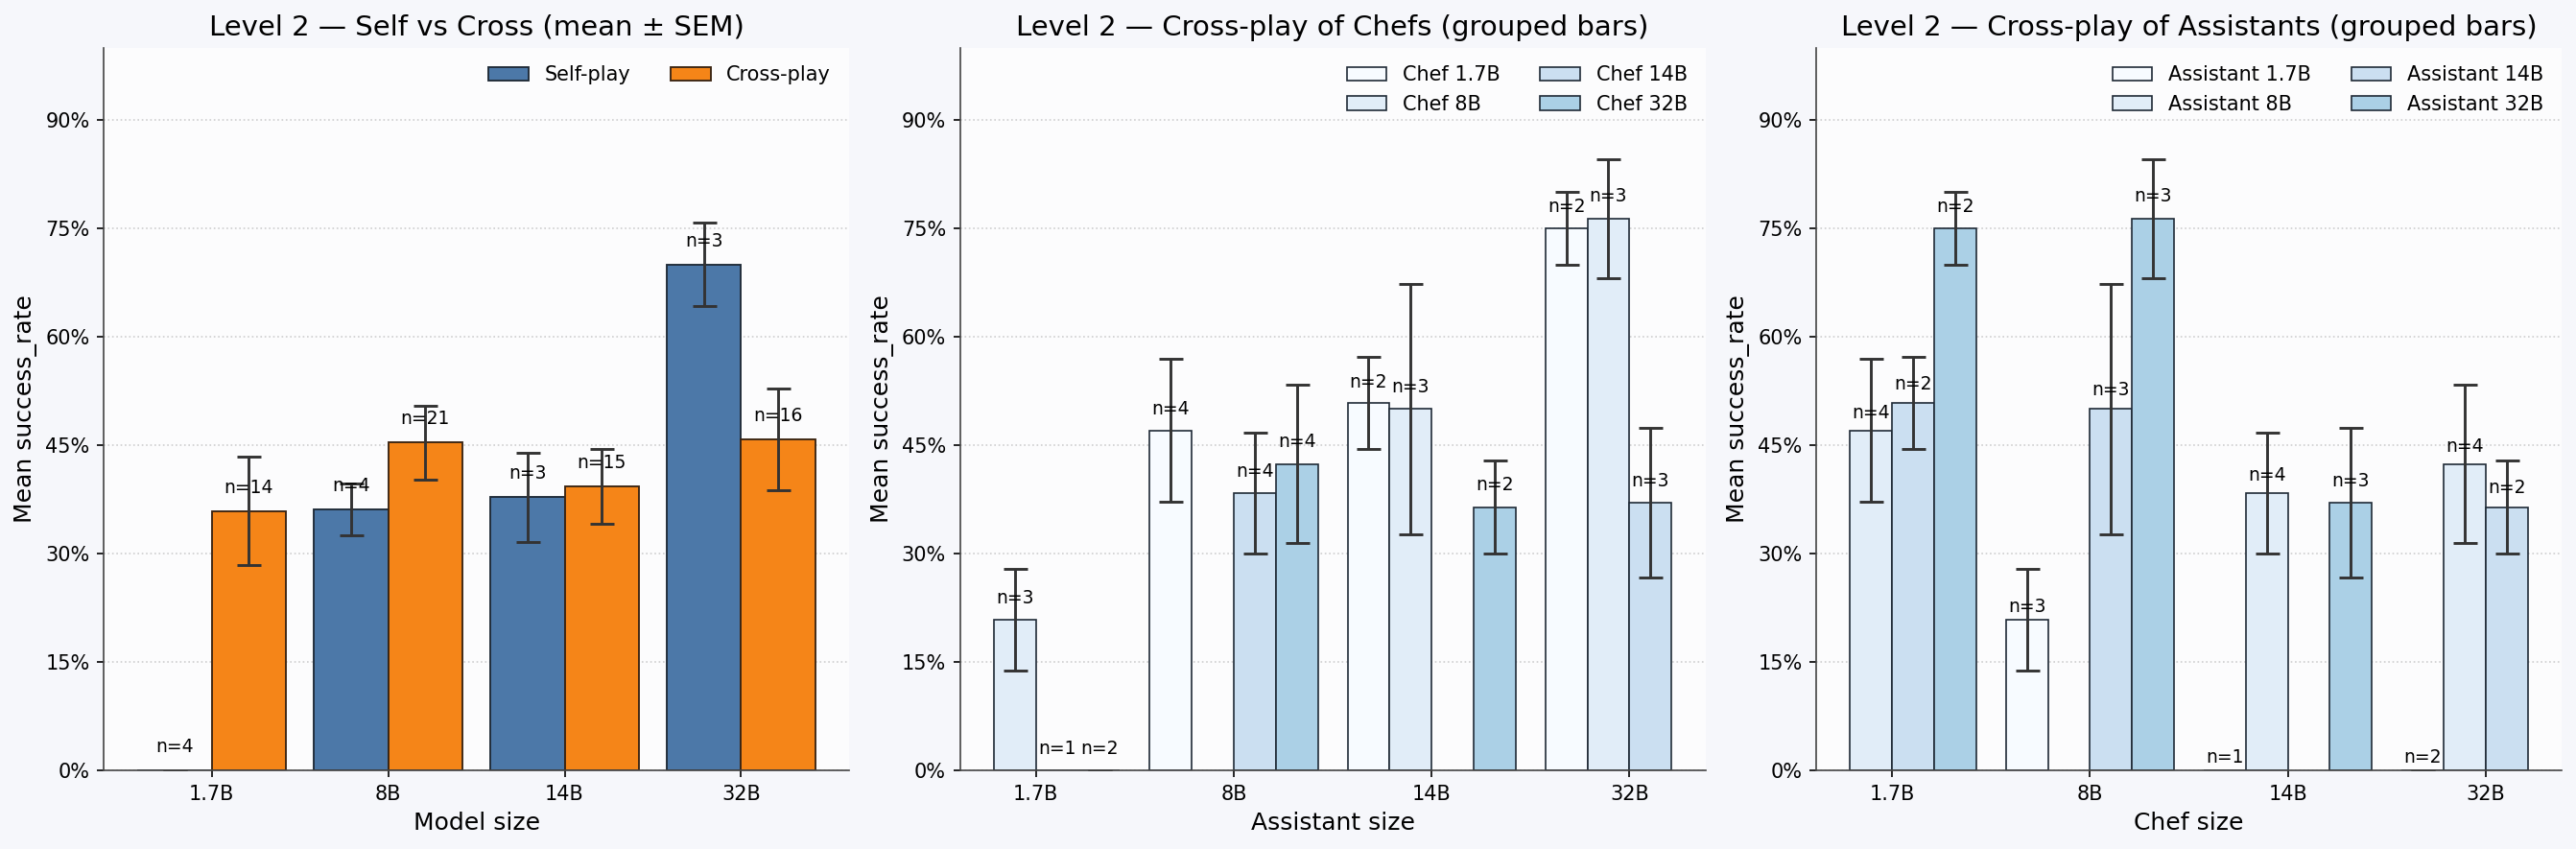

Saved -> ./plots/level_2__composite_bars.png


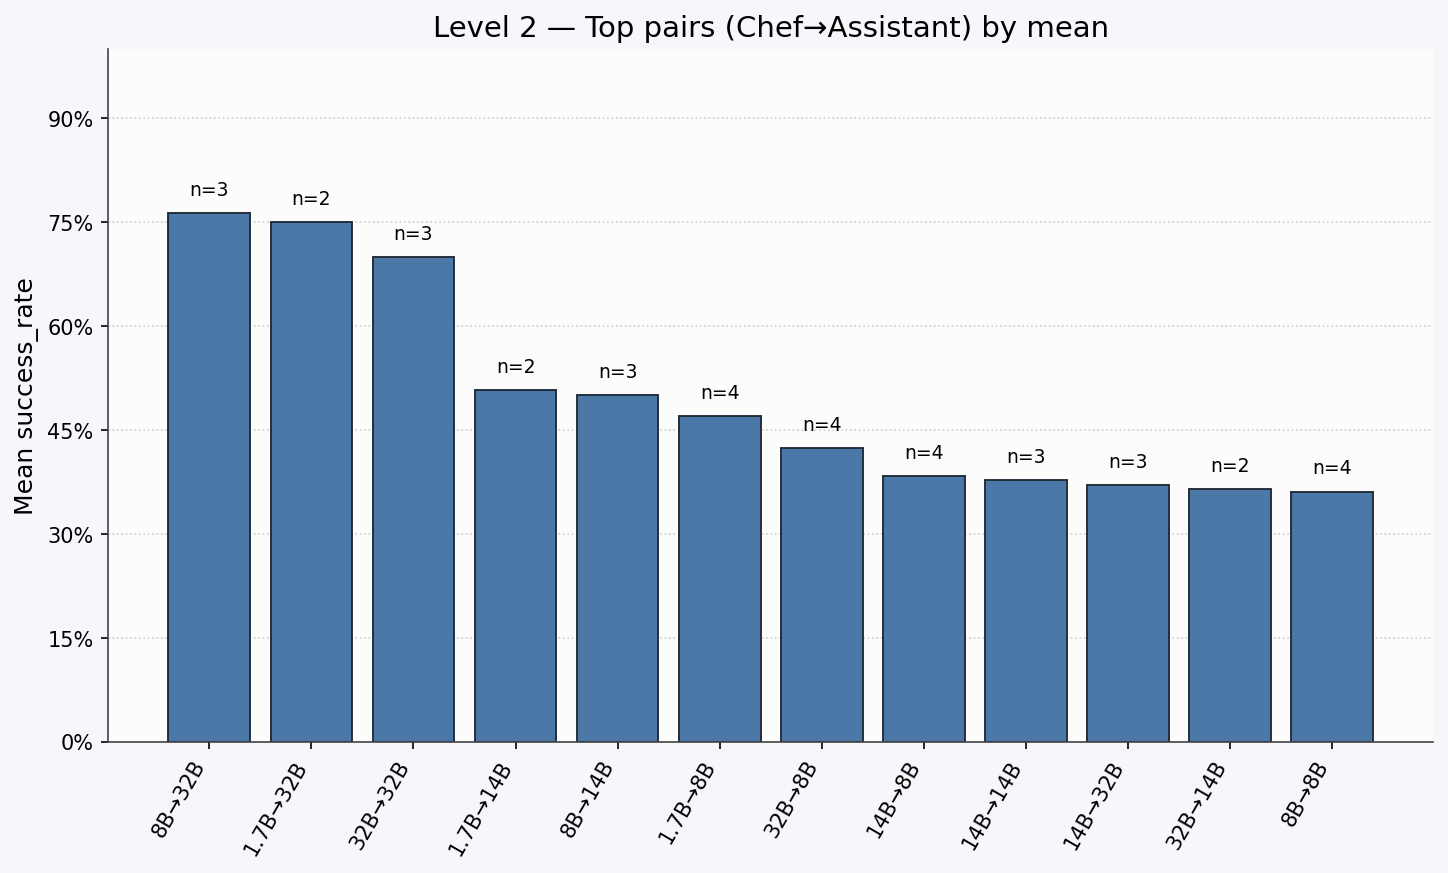

Saved -> ./plots/level_2__top_pairs.png
[Level 2] sizes: ['1.7B', '8B', '14B', '32B']
  Chef sizes: ['1.7B', '8B', '14B', '32B']
  Assistant sizes: ['1.7B', '8B', '14B', '32B']


In [6]:
# NumPy + matplotlib (no pandas)
# Per-level composite figure with 3 panels:
#   (1) Self vs Cross — mean success_rate ± SEM by model size (grouped bars)
#   (2) Cross-play of Chefs — x=Assistant size, series=Chef size (grouped bars)
#   (3) Cross-play of Assistants — x=Chef size, series=Assistant size (grouped bars)
# Plus an additional per-level figure:
#   (4) Top pairs (Chef→Assistant) by mean, directional, with optional self-play entries
#
# Role mapping (agreed):
#   agent_0 = Chef (first model in 'model' string)
#   agent_1 = Assistant (second model in 'model' string)

import os
import numpy as np
import csv
import re
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from collections import defaultdict

# ---------- Config ----------
INPUT_CANDIDATES = ["statistics_data_symmetric_data.csv"]
OUT_DIR = "./plots"
VERBOSE_SUMMARY = True   # set False to suppress console summaries
SHOW_IN_NOTEBOOK = True  # show figures inline (and also save them)

# Distinct, readable base colors for self/cross; series will use a palette.
COLORS = {"self": "#4C78A8", "cross": "#F58518"}  # blue / orange

# Whether to draw "n=.." on top of each bar
ANNOTATE_COUNTS = True

# New: configuration for Top Pairs figure
TOP_PAIRS_COUNT = 12        # number of top Chef→Assistant size pairs to plot
INCLUDE_SELF_IN_TOP = True  # include sz→sz self-play entries in top-pairs ranking

# Style tweaks for a clean, modern look
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
})

# ---------- Helpers ----------
def find_path(cands):
    for p in cands:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV at any of: {cands}")

def parse_pair(model_str):
    # Expect pattern like "Vendor_ModelA-Vsize_Vendor_ModelB-Vsize"
    parts = model_str.split("_")
    if len(parts) >= 4:
        a = parts[0] + "_" + parts[1]  # agent_0 (Chef)
        b = parts[2] + "_" + parts[3]  # agent_1 (Assistant)
    else:
        mid = len(parts) // 2
        a = "_".join(parts[:mid])
        b = "_".join(parts[mid:])
    return a, b

_size_regex = re.compile(r'(\d+(?:\.\d+)?)\s*[Bb]\b')

def extract_size(label):
    # Try last hyphen token first (e.g., "Qwen3-32B" -> "32B")
    toks = label.split("-")
    for tok in reversed(toks):
        tok = tok.strip()
        if tok and (tok[-1] in "Bb"):
            m = _size_regex.match(tok)
            if m:
                num = m.group(1)
                return f"{num}B"
    # Fallback: search anywhere
    m = _size_regex.search(label)
    if m:
        return f"{m.group(1)}B"
    return None

def sem(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return float("nan")
    return float(np.std(x, ddof=1) / np.sqrt(n))

def size_key(sz):
    try:
        return float(sz[:-1])
    except Exception:
        return float("inf")

def polish_axes(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_facecolor("#FCFCFD")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

def format_as_percent_if_applicable(ax, ymax_est):
    # If success_rate is in [0,1], swap to % ticks.
    if np.isfinite(ymax_est) and ymax_est <= 1.05:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v*100:.0f}%"))
        ax.set_ylim(0, max(1.0, ymax_est))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

def sanitize_token(s):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s))

def show_and_save(fig, path):
    # display first (for notebooks), then save, then close
    if SHOW_IN_NOTEBOOK:
        try:
            from IPython.display import display
            display(fig)
        except Exception:
            try:
                plt.show()
            except Exception:
                pass
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("Saved ->", path)

def collect_mean_sem_n(vals):
    vals = np.asarray(vals, dtype=float)
    n = int(vals.size)
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(np.mean(vals)), sem(vals), n

def plot_grouped_bars(ax, x_labels, series_keys, mean_map, sem_map, n_map,
                      color_map, label_prefix, error_kw):
    """
    x_labels: ordered list of category labels for the x-axis
    series_keys: ordered list of series (each will be a grouped bar)
    mean_map[series_key][x_label] -> mean
    sem_map[series_key][x_label]  -> sem
    n_map[series_key][x_label]    -> n
    color_map: callable int->color, e.g., plt.cm.get_cmap("tab10", K)
    """
    x = np.arange(len(x_labels), dtype=float)
    k = max(1, len(series_keys))
    width = min(0.85 / k, 0.28)  # keep bars readable even with many series

    ymax_est = 0.0
    for i, sk in enumerate(series_keys):
        heights = [mean_map[sk].get(lbl, float("nan")) for lbl in x_labels]
        errors  = [sem_map[sk].get(lbl,  float("nan")) for lbl in x_labels]
        counts  = [n_map[sk].get(lbl,    0)             for lbl in x_labels]

        # Bar centers for this series
        pos = x + (i - (k - 1) / 2.0) * width

        bars = ax.bar(pos, heights, width,
                      yerr=errors,
                      label=f"{label_prefix} {sk}",
                      color=color_map(i),
                      edgecolor="#1f2a36",
                      linewidth=0.8,
                      error_kw=error_kw)

        # Annotation and local ymax aggregation
        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin if ymax > ymin else 1.0
        for rect, h, n in zip(bars, heights, counts):
            if not np.isfinite(h):
                continue
            ymax_est = max(ymax_est, float(h) + (errors[0] if (len(errors) and np.isfinite(errors[0])) else 0.0))
            if ANNOTATE_COUNTS:
                ax.text(rect.get_x() + rect.get_width()/2.0,
                        rect.get_height() + 0.02 * yrange,
                        f"n={n}", ha="center", va="bottom", fontsize=9)

    # Finalize x axis
    ax.set_xticks(x, x_labels)
    return ymax_est

# ---------- Load ----------
path = find_path(INPUT_CANDIDATES)

# Aggregates
# buckets_by_size[(level, size, type)] -> list[success_rate], type in {"self","cross"}  (size = generic size bucket)
buckets_by_size = defaultdict(list)

# Cross decomposition matrices (role aware)
# cross_matrix[level][chef_size][assistant_size] -> list[success_rate]
cross_matrix = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Track which sizes appear as chef vs assistant, per level
chef_sizes_by_level = defaultdict(set)
assistant_sizes_by_level = defaultdict(set)

levels_seen = set()
sizes_seen_by_level = defaultdict(set)  # for combined self vs cross chart

with open(path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            sr = float(row["success_rate"])
            model_str = row["model"]
            level = row["level"]
        except (KeyError, ValueError):
            continue
        if not level:
            continue

        a, b = parse_pair(model_str)
        sa = extract_size(a)  # agent_0 (Chef)
        sb = extract_size(b)  # agent_1 (Assistant)
        if sa is None or sb is None:
            continue

        levels_seen.add(level)
        sizes_seen_by_level[level].update([sa, sb])

        # Self vs Cross (size-agnostic of role)
        if sa == sb:
            buckets_by_size[(level, sa, "self")].append(sr)
        else:
            # count cross for both sizes in the size-based view
            buckets_by_size[(level, sa, "cross")].append(sr)
            buckets_by_size[(level, sb, "cross")].append(sr)

            # role-aware cross matrices
            cross_matrix[level][sa][sb].append(sr)  # Chef=sa, Assistant=sb
            chef_sizes_by_level[level].add(sa)
            assistant_sizes_by_level[level].add(sb)

# Sort levels (numeric if possible, else lexical)
def level_key(x):
    try:
        return (0, float(x))
    except Exception:
        return (1, str(x))
levels_sorted = sorted(levels_seen, key=level_key)

# ---------- Per-level composite figures (3 panels each) ----------
os.makedirs(OUT_DIR, exist_ok=True)
error_kw_common = dict(ecolor="#333333", linewidth=1.4, capsize=6, capthick=1.4)

for lvl in levels_sorted:

    # Prepare panel (1): Self vs Cross grouped bars by size
    sizes_sorted = sorted(sizes_seen_by_level[lvl], key=size_key)

    means_self_all, sems_self_all, n_self_all = [], [], []
    means_cross_all, sems_cross_all, n_cross_all = [], [], []
    for sz in sizes_sorted:
        xs = np.array(buckets_by_size.get((lvl, sz, "self"), []), dtype=float)
        xc = np.array(buckets_by_size.get((lvl, sz, "cross"), []), dtype=float)

        m_s, s_s, n_s = collect_mean_sem_n(xs)
        m_c, s_c, n_c = collect_mean_sem_n(xc)

        means_self_all.append(m_s); sems_self_all.append(s_s); n_self_all.append(n_s)
        means_cross_all.append(m_c); sems_cross_all.append(s_c); n_cross_all.append(n_c)

    # Prepare panels (2) and (3): role-aware cross matrices
    chef_sizes = sorted(chef_sizes_by_level[lvl], key=size_key)
    assistant_sizes = sorted(assistant_sizes_by_level[lvl], key=size_key)

    # Build mean/sem/n maps for grouped bars
    # (2) series=Chef size, x=Assistant size
    means_Chef, sems_Chef, ns_Chef = {}, {}, {}
    for csz in chef_sizes:
        means_Chef[csz], sems_Chef[csz], ns_Chef[csz] = {}, {}, {}
        for asz in assistant_sizes:
            m, s, n = collect_mean_sem_n(cross_matrix[lvl][csz].get(asz, []))
            means_Chef[csz][asz] = m
            sems_Chef[csz][asz] = s
            ns_Chef[csz][asz] = n

    # (3) series=Assistant size, x=Chef size
    means_Asst, sems_Asst, ns_Asst = {}, {}, {}
    for asz in assistant_sizes:
        means_Asst[asz], sems_Asst[asz], ns_Asst[asz] = {}, {}, {}
        for csz in chef_sizes:
            m, s, n = collect_mean_sem_n(cross_matrix[lvl][csz].get(asz, []))
            means_Asst[asz][csz] = m
            sems_Asst[asz][csz] = s
            ns_Asst[asz][csz] = n

    # Create the 1x3 composite figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor("#F6F7FB")

    # ========= Panel (1): Self vs Cross =========
    ax = axes[0]
    x = np.arange(len(sizes_sorted))
    width = 0.42

    # ymax estimate for percent formatting
    a = np.nan_to_num(np.array(means_self_all),  nan=0.0) + np.nan_to_num(np.array(sems_self_all),  nan=0.0)
    b = np.nan_to_num(np.array(means_cross_all), nan=0.0) + np.nan_to_num(np.array(sems_cross_all), nan=0.0)
    ymax_est1 = float(max(np.max(a) if a.size else 0.0, np.max(b) if b.size else 0.0))

    b1 = ax.bar(x - width/2, means_self_all,  width, yerr=sems_self_all,  label="Self-play",
                color=COLORS["self"],  edgecolor="#1f2a36", linewidth=0.9, error_kw=error_kw_common)
    b2 = ax.bar(x + width/2, means_cross_all, width, yerr=sems_cross_all, label="Cross-play",
                color=COLORS["cross"], edgecolor="#3a2412", linewidth=0.9, error_kw=error_kw_common)

    ax.set_xticks(x, sizes_sorted)
    ax.set_xlabel("Model size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Self vs Cross (mean ± SEM)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est1)
    ax.legend(frameon=False, ncol=2)

    # annotate sample sizes
    ymin, ymax = ax.get_ylim(); yrange = ymax - ymin
    for rect, n in zip(b1, n_self_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)
    for rect, n in zip(b2, n_cross_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)

    # ========= Panel (2): Cross-play of Chefs (grouped bars) =========
    ax = axes[1]
    cmap_C = plt.cm.get_cmap("Blues", max(10, len(chef_sizes)))
    ymax_est2 = plot_grouped_bars(ax,
                                  x_labels=assistant_sizes,
                                  series_keys=chef_sizes,
                                  mean_map=means_Chef,
                                  sem_map=sems_Chef,
                                  n_map=ns_Chef,
                                  color_map=cmap_C,
                                  label_prefix="Chef",
                                  error_kw=error_kw_common)
    ax.set_xlabel("Assistant size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Cross-play of Chefs (grouped bars)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est2 if np.isfinite(ymax_est2) else np.nan)
    ax.legend(frameon=False, ncol=2)

    # ========= Panel (3): Cross-play of Assistants (grouped bars) =========
    ax = axes[2]
    cmap_A = plt.cm.get_cmap("Blues", max(10, len(assistant_sizes)))
    ymax_est3 = plot_grouped_bars(ax,
                                  x_labels=chef_sizes,
                                  series_keys=assistant_sizes,
                                  mean_map=means_Asst,
                                  sem_map=sems_Asst,
                                  n_map=ns_Asst,
                                  color_map=cmap_A,
                                  label_prefix="Assistant",
                                  error_kw=error_kw_common)
    ax.set_xlabel("Chef size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Cross-play of Assistants (grouped bars)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est3 if np.isfinite(ymax_est3) else np.nan)
    ax.legend(frameon=False, ncol=2)

    # Layout + save the composite
    fig.tight_layout()
    composite_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__composite_bars.png")
    show_and_save(fig, composite_png)

    # ========= Additional Figure: Top pairs (Chef→Assistant) by mean =========
    # Directional: 32B→8B is distinct from 8B→32B. Self-play entries (sz→sz) are added only if configured.
    pairs = []

    # Cross-play (directional)
    for csz in chef_sizes:
        row_means = means_Chef.get(csz, {})
        row_ns    = ns_Chef.get(csz, {})
        for asz in assistant_sizes:
            m = row_means.get(asz, float("nan"))
            n = row_ns.get(asz, 0)
            if np.isfinite(m) and n > 0:
                # Tie-break on larger samples via log(n)
                pairs.append((m, math.log(max(1, n) + 1.0), n, csz, asz))

    # Optional: include self-play as sz→sz using self buckets
    if INCLUDE_SELF_IN_TOP:
        for sz in sizes_sorted:
            m_s, s_s, n_s = collect_mean_sem_n(buckets_by_size.get((lvl, sz, "self"), []))
            if np.isfinite(m_s) and n_s > 0:
                pairs.append((m_s, math.log(max(1, n_s) + 1.0), n_s, sz, sz))

    if pairs:
        pairs.sort(key=lambda t: (t[0], t[1]), reverse=True)
        top = pairs[:max(1, TOP_PAIRS_COUNT)]

        labels = [f"{cm}→{am}" for (_, _, _, cm, am) in top]
        means  = [m for (m, _, _, _, _) in top]
        counts = [n for (_, _, n, _, _) in top]

        fig_tp = plt.figure(figsize=(max(10, 0.45*len(top) + 6), 6))
        ax_tp  = fig_tp.add_subplot(111); fig_tp.patch.set_facecolor("#F6F7FB")

        x = np.arange(len(top))
        bars = ax_tp.bar(x, means, edgecolor="#1f2a36", linewidth=0.9, color=COLORS["self"])
        ax_tp.set_xticks(x, labels, rotation=60, ha="right")
        ax_tp.set_ylabel("Mean success_rate")
        ax_tp.set_title(f"Level {lvl} — Top pairs (Chef→Assistant) by mean")
        polish_axes(ax_tp)

        ymax_est = float(max(means)) if means else float("nan")
        format_as_percent_if_applicable(ax_tp, ymax_est)

        ymin, ymax = ax_tp.get_ylim(); yrange = ymax - ymin
        if ANNOTATE_COUNTS:
            for rect, n in zip(bars, counts):
                h = rect.get_height()
                if np.isfinite(h):
                    ax_tp.text(rect.get_x() + rect.get_width()/2.0,
                               h + 0.02*yrange,
                               f"n={n}",
                               ha="center", va="bottom", fontsize=9)

        out_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__top_pairs.png")
        show_and_save(fig_tp, out_png)

    if VERBOSE_SUMMARY:
        print(f"[Level {lvl}] sizes: {sizes_sorted}")
        print(f"  Chef sizes: {chef_sizes}")
        print(f"  Assistant sizes: {assistant_sizes}")
